In [1]:
from google.colab import files

uploaded = files.upload()

Saving time_series_60min_singleindex.csv to time_series_60min_singleindex.csv


In [2]:
import pandas as pd

df = pd.read_csv('time_series_60min_singleindex.csv')

print(df.shape)
print(df.columns[:30])

(50401, 300)
Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual',
       'BE_wind_onshore_generation_actual',
       'BG_load_actual_entsoe_transparency',
       'BG_load_forecast_entsoe_transparency', 'BG_solar_generation_actual',
       'BG_wind_onshore_generation_actual',
       'CH_load_actual_entsoe_transparency',
       'CH_load_forecast_entsoe_transparency', 'CH_solar_capacity',
       'CH_solar_generation_actual', 'CH_wind_onshore_capacity',
       'CH_wind_onshore_generation_actual',
       'CY_load_actual_entsoe_transparency',
       'CY_load_forecast_entsoe_transparency',
       'CY_wind_onshore_generatio

In [3]:
#choosing germany market
de_cols = [c for c in df.columns if c.startswith('DE')]

for c in de_cols:
    print(c)

DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation_actual
DE_amprion_load_actual_entsoe_transparency
DE_amprion_load_forecast_entsoe_transparency
DE_amprion_solar_generation_actual
DE_amprion_wind_onshore_generation_actu

In [4]:
#dataset creation
energy = df[['utc_timestamp','DE_LU_price_day_ahead']].copy()

energy.columns = ['date','price']

energy['date'] = pd.to_datetime(energy['date'])

energy = energy.set_index('date')

energy = energy.dropna()

print(energy.head())
print(energy.shape)

                           price
date                            
2018-09-30 23:00:00+00:00  56.10
2018-10-01 00:00:00+00:00  51.41
2018-10-01 01:00:00+00:00  47.38
2018-10-01 02:00:00+00:00  47.59
2018-10-01 03:00:00+00:00  51.61
(17540, 1)


In [12]:
#Exploratory Data Analysis
energy.info()
energy.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17540 entries, 2018-09-30 23:00:00+00:00 to 2020-09-30 22:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   17540 non-null  float64
dtypes: float64(1)
memory usage: 274.1 KB


,price
count,17540.000000
mean,35.809288
std,18.137177
min,-90.010000
25%,26.717500
50%,36.150000
75%,46.030000
max,200.040000


Οι αρνητικές τιμές εμφανίζονται όταν:

υπάρχει υπερπαραγωγή,
υψηλή διείσδυση ΑΠΕ,
χαμηλή ζήτηση,
οι παραγωγοί πληρώνουν για να παραμείνουν συνδεδεμένοι.

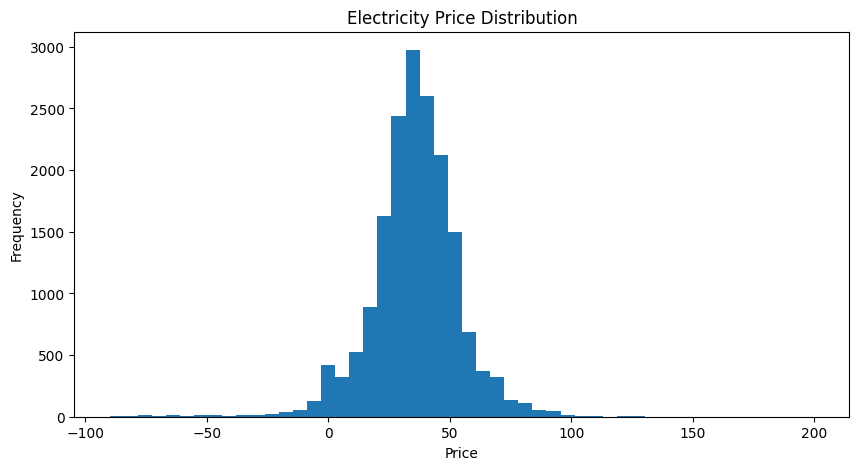

In [6]:
#histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(energy['price'], bins=50)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Electricity Price Distribution')

plt.show()

In [7]:
#skewness & curtosis
from scipy.stats import skew, kurtosis

print('Skewness:', skew(energy['price']))
print('Kurtosis:', kurtosis(energy['price']))

Skewness: -0.5117598948506857
Kurtosis: 4.964058192439272


Η κατανομή είναι ελαφρώς αριστερά ασύμμετρη.

Δηλαδή:

υπάρχουν περισσότερα ακραία αρνητικά γεγονότα,
εμφανίζονται price crashes,
κάτι που είναι χαρακτηριστικό των electricity markets.
Fat Tails

Δηλαδή:

ακραίες παρατηρήσεις,
spikes,
volatility clusters,
μη Gaussian συμπεριφορά.

Για τις αγορές ηλεκτρικής ενέργειας συνήθως βλέπουμε:

skewness ≠ 0
kurtosis >> 3

Αυτό δείχνει:

μη κανονικότητα
fat tails
extreme events
Skewness (-0.51): Η τιμή αυτή είναι διαφορετική από το 0, υποδηλώνοντας ασυμμετρία στην κατανομή.
Kurtosis (4.96): Η τιμή αυτή είναι σημαντικά μεγαλύτερη από το 3 (την kurtosis μιας κανονικής κατανομής), υποδηλώνοντας "fat tails" (παχιές ουρές) και "extreme events" (ακραία γεγονότα) στην κατανομή. Αυτό σημαίνει ότι υπάρχουν περισσότερες ακραίες τιμές από ό,τι θα περιμέναμε σε μια κανονική κατανομή.
Συνολικά, το τεστ Jarque-Bera με την p-value 0.0 υποστηρίζει πλήρως την παρατήρηση ότι οι τιμές ηλεκτρικής ενέργειας παρουσιάζουν χαρακτηριστικά μη κανονικότητας, παχιές ουρές και την εμφάνιση ακραίων γεγονότων, όπως ακριβώς αναφέρθηκε στην προηγούμενη περιγραφή σας για τις αγορές ηλεκτρικής ενέργειας.


In [8]:
#Jarque-Bera Test
from scipy.stats import jarque_bera

jb = jarque_bera(energy['price'])

print(jb)

SignificanceResult(statistic=np.float64(18774.718432166883), pvalue=np.float64(0.0))


p<0.05 so we reject the ho hypothesis
Οι τιμές ηλεκτρικής ενέργειας:

δεν ακολουθούν κανονική κατανομή,
έχουν skewness,
έχουν heavy tails,
παρουσιάζουν ακραία γεγονότα.

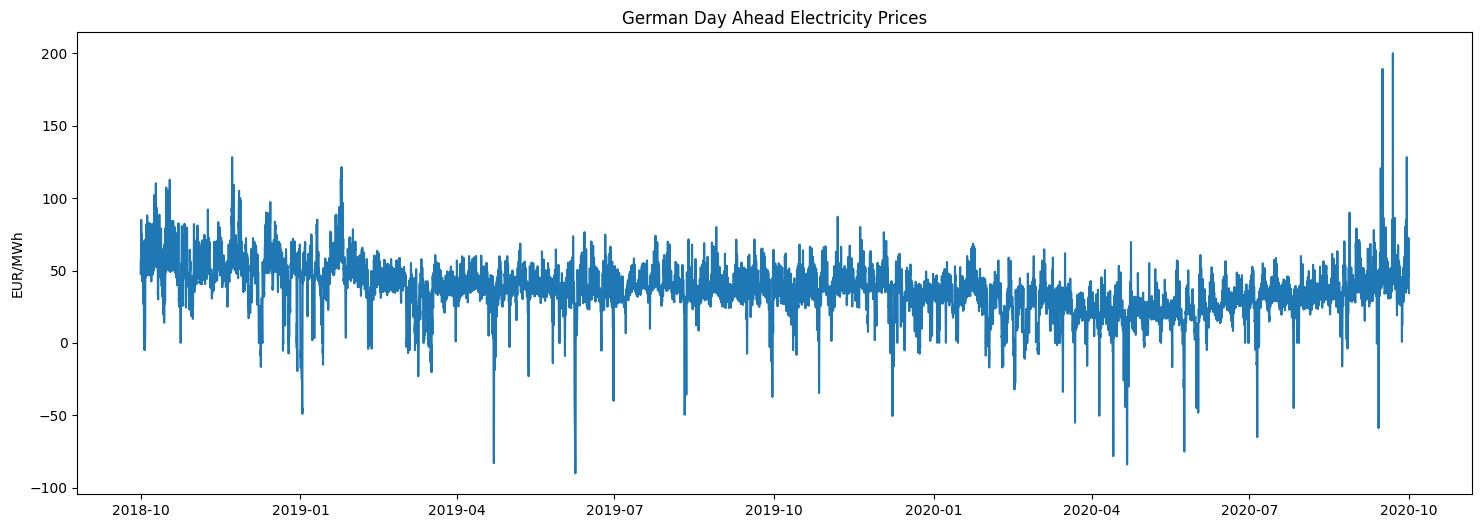

In [9]:
#Time Series Plot
plt.figure(figsize=(18,6))

plt.plot(energy.index,
         energy['price'])

plt.title('German Day Ahead Electricity Prices')
plt.ylabel('EUR/MWh')

plt.show()

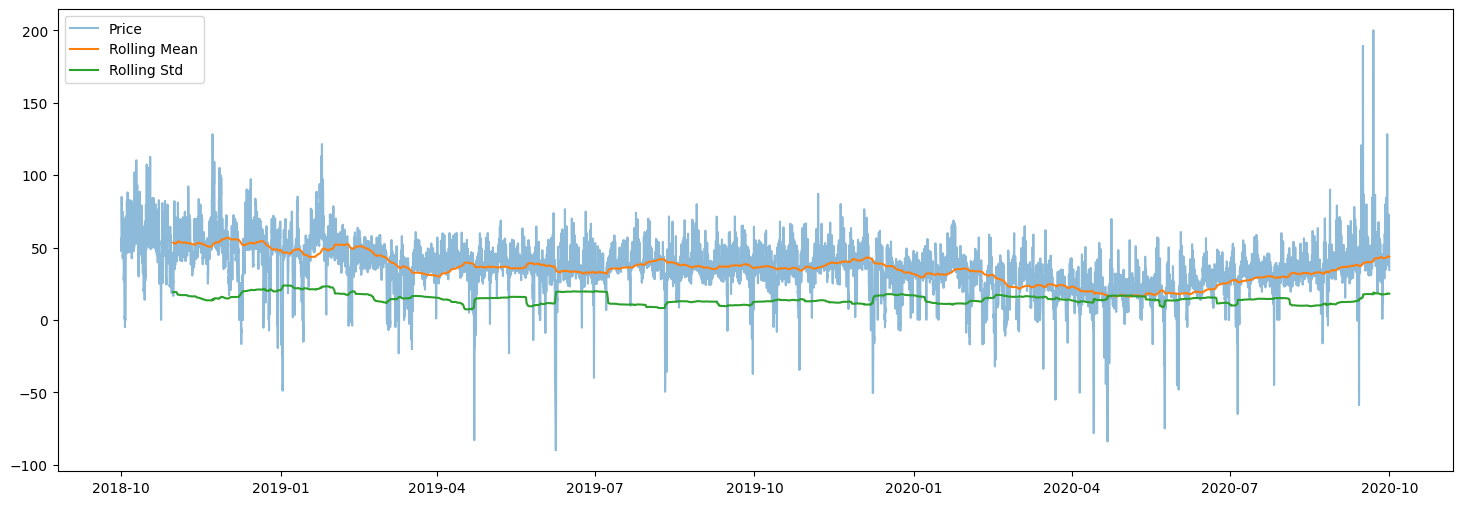

In [10]:
#rolling statistics
rolling_mean = energy['price'].rolling(24*30).mean()

rolling_std = energy['price'].rolling(24*30).std()

plt.figure(figsize=(18,6))

plt.plot(energy['price'],
         alpha=0.5)

plt.plot(rolling_mean)

plt.plot(rolling_std)

plt.legend([
    'Price',
    'Rolling Mean',
    'Rolling Std'
])

plt.show()

## Distributional Analysis of German Day-Ahead Electricity Prices

The descriptive analysis reveals several stylized facts commonly observed in electricity markets. The average day-ahead price was 35.81 EUR/MWh with a standard deviation of 18.14 EUR/MWh. Negative prices were observed, with a minimum value of -90.01 EUR/MWh, indicating periods of excess generation and low demand conditions.

The distribution exhibits negative skewness (-0.51), suggesting the presence of asymmetric downside price movements. Furthermore, the kurtosis value (4.96) exceeds the benchmark value of 3 associated with the normal distribution, indicating fat-tailed behavior and the occurrence of extreme price events.

The Jarque-Bera normality test strongly rejects the null hypothesis of normality (p-value < 0.001), confirming that electricity prices do not follow a Gaussian distribution. This finding motivates the use of volatility models such as GARCH and risk measures designed for heavy-tailed distributions.


In [18]:
#stationarity test
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

adf = adfuller(energy['price'])

print('ADF Statistic:', adf[0])
print('ADF p-value:', adf[1])

kpss_result = kpss(energy['price'])

print('KPSS Statistic:', kpss_result[0])
print('KPSS p-value:', kpss_result[1])

ADF Statistic: -9.620182777829227
ADF p-value: 1.7173670770703446e-16
KPSS Statistic: 8.07967205911615
KPSS p-value: 0.01


/tmp/ipykernel_661/3948271798.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(energy['price'])


Συμπέρασμα ADF:

✅ Η χρονοσειρά φαίνεται στάσιμη.
Συμπέρασμα KPSS:

❌ Η χρονοσειρά δεν είναι στάσιμη.
Οι τιμές ηλεκτρικής ενέργειας συχνά έχουν:

βραχυχρόνια stationarity,
έντονη ημερήσια εποχικότητα,
εβδομαδιαία εποχικότητα,
volatility clustering,
structural breaks.

Γι' αυτό:

ο ADF "βλέπει" stationarity,
ο KPSS "βλέπει" non-stationarity.

Στην πράξη, όταν έχουμε αυτή τη σύγκρουση, προχωράμε σε:

decomposition,
ACF/PACF,
πιθανό seasonal differencing.

Stationarity Analysis

Stationarity was assessed using both the Augmented Dickey-Fuller (ADF) and KPSS tests. The ADF test rejected the null hypothesis of a unit root (ADF statistic = -9.62, p-value < 0.001), suggesting that the series is stationary. However, the KPSS test rejected the null hypothesis of stationarity (KPSS statistic = 8.08, p-value < 0.01).

The conflicting outcomes indicate that the electricity price series exhibits complex stochastic behavior, which is common in power markets due to strong seasonal effects, structural breaks, and volatility clustering. Therefore, additional diagnostic procedures, including autocorrelation analysis and seasonal decomposition, are required before model specification.

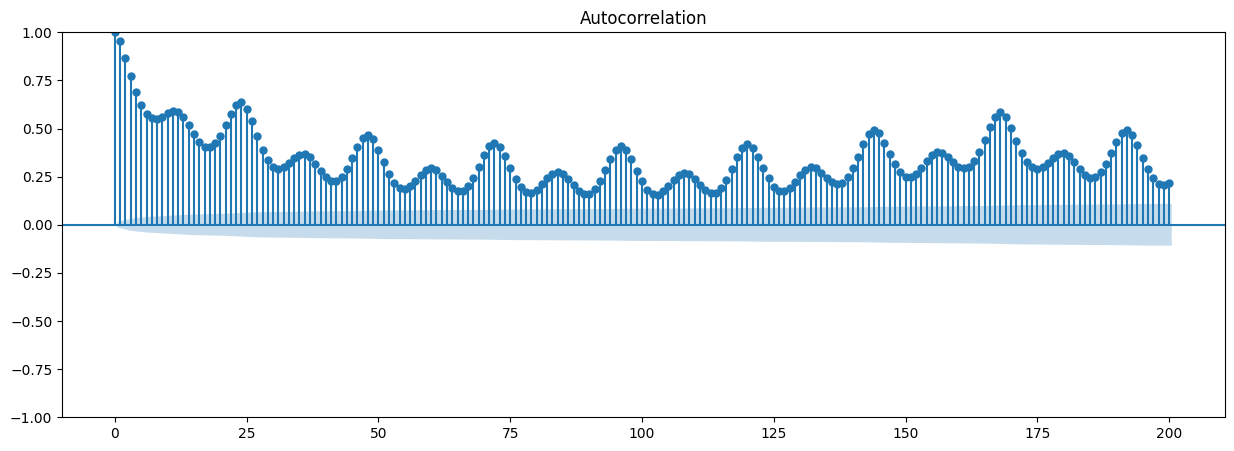

In [19]:
#Autocorrelation Analysis
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,5))
plot_acf(energy['price'],
         lags=200,
         ax=ax)

plt.show()

Το ACF δείχνει κάτι πολύ ενδιαφέρον:

πολύ υψηλή αυτοσυσχέτιση στα πρώτα lags,
αργή αποσύνθεση,
ξεκάθαρες κορυφές στα:
24 ώρες,
48 ώρες,
72 ώρες,
96 ώρες,
κτλ.

Αυτό σημαίνει ότι υπάρχει:

Ισχυρή ημερήσια εποχικότητα

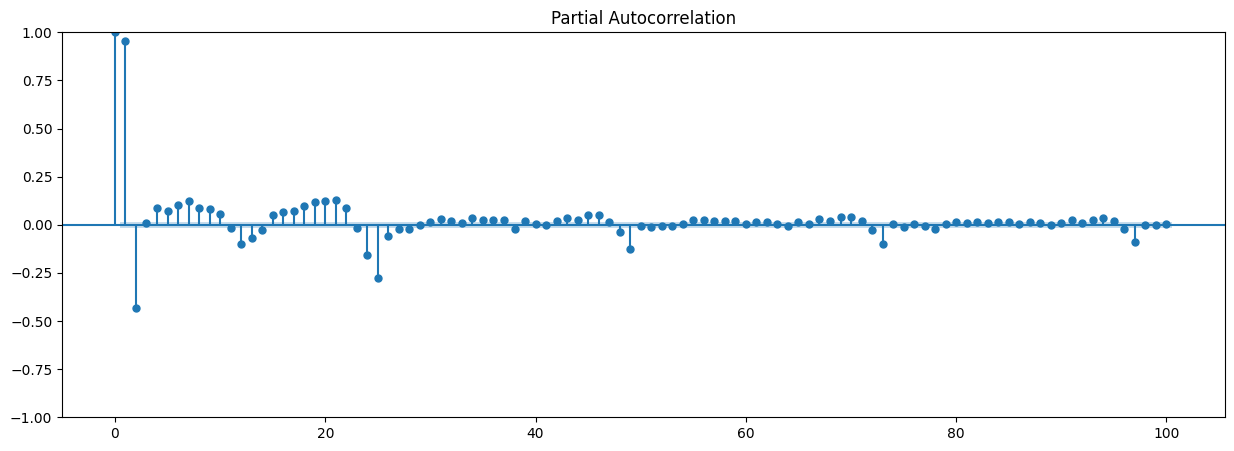

In [20]:
fig, ax = plt.subplots(figsize=(15,5))
plot_pacf(energy['price'],
          lags=100,
          ax=ax)

plt.show()

Το PACF δείχνει:

πολύ ισχυρό lag 1,
σημαντικά lags μέχρι περίπου 2–3,
επαναλαμβανόμενη δομή γύρω από το 24.

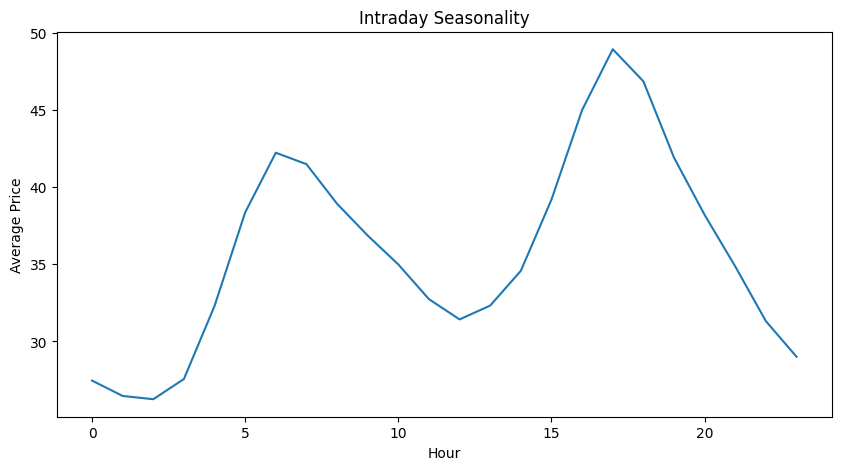

In [21]:
hourly = energy.groupby(
    energy.index.hour
)['price'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly)

plt.xlabel('Hour')
plt.ylabel('Average Price')
plt.title('Intraday Seasonality')

plt.show()

Νυχτερινές ώρες
00:00–04:00

χαμηλές τιμές.

Πρωινή κορυφή
06:00–08:00

λόγω εκκίνησης βιομηχανίας και νοικοκυριών.

Απογευματινή κορυφή
16:00–18:00

που είναι η κλασική peak ώρα στη Γερμανία.

date
0    37.712988
1    38.335766
2    39.530881
3    40.629331
4    39.167600
5    29.992748
6    25.206065
Name: price, dtype: float64


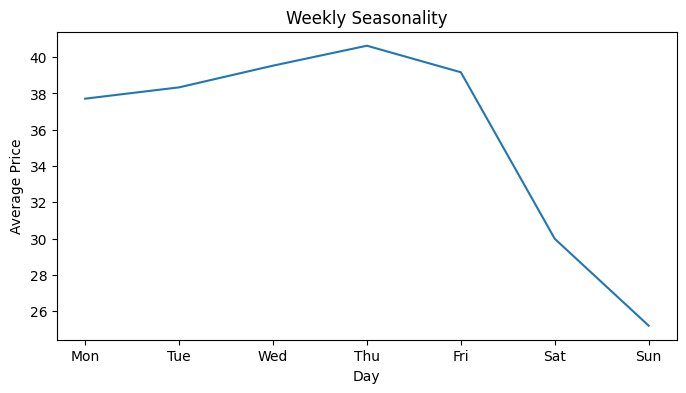

In [24]:
weekly = energy.groupby(
    energy.index.dayofweek
)['price'].mean()

print(weekly)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(weekly)

plt.xticks(
    range(7),
    ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
)

plt.xlabel('Day')
plt.ylabel('Average Price')
plt.title('Weekly Seasonality')

plt.show()

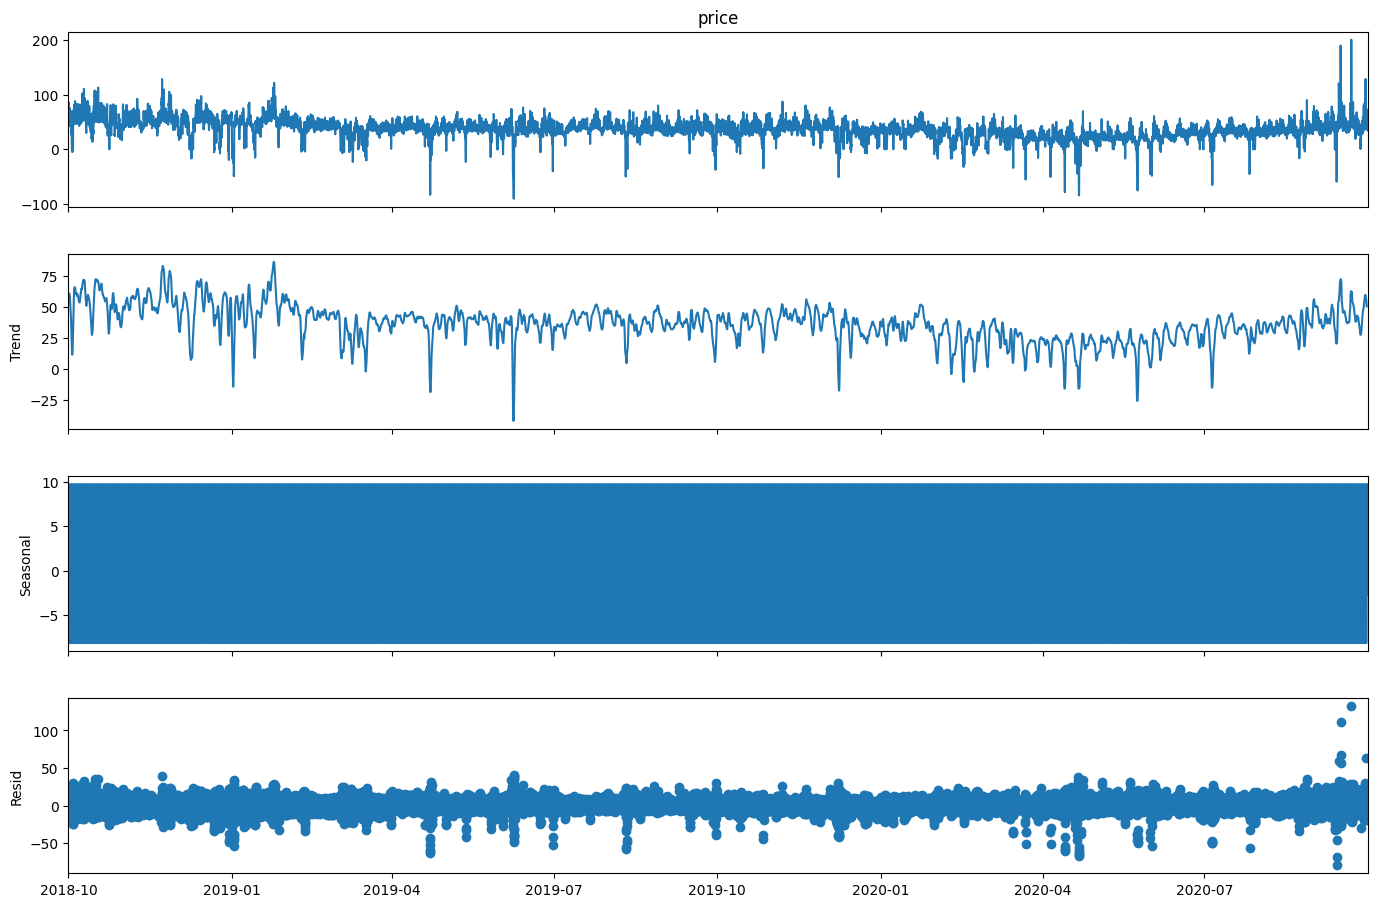

In [25]:
#seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    energy['price'],
    model='additive',
    period=24
)

fig = decomposition.plot()
fig.set_size_inches(15,10)

plt.show()

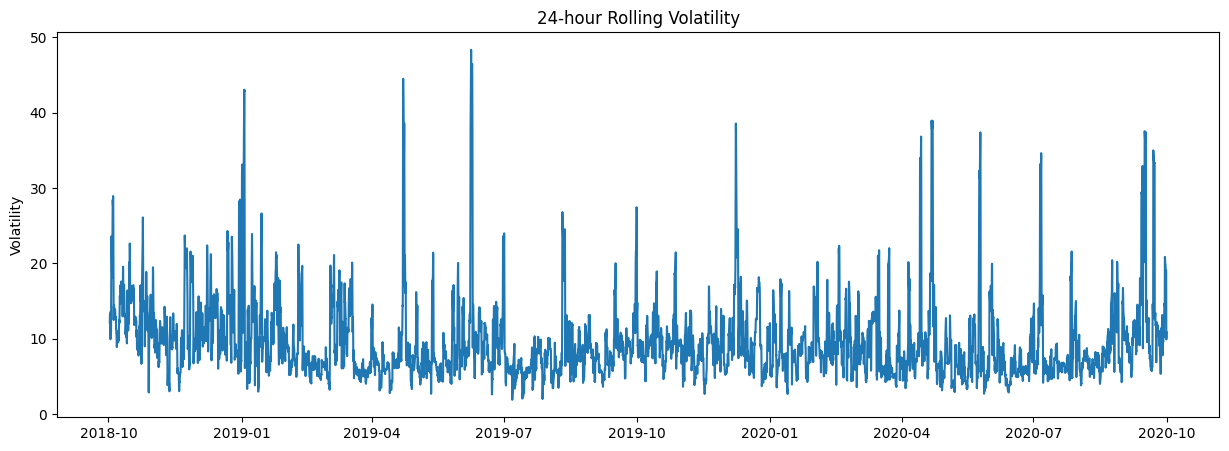

In [26]:
rolling_vol = energy['price'].rolling(24).std()

plt.figure(figsize=(15,5))

plt.plot(rolling_vol)

plt.title('24-hour Rolling Volatility')

plt.ylabel('Volatility')

plt.show()

In [27]:
#check for arch effects
from statsmodels.stats.diagnostic import het_arch

stat, pvalue, _, _ = het_arch(
    energy['price'].dropna()
)

print("ARCH Statistic:", stat)
print("p-value:", pvalue)

ARCH Statistic: 14476.585206872998
p-value: 0.0


In [29]:
#sarima model
#train/test split
train_size = int(len(energy)*0.8)

train = energy['price'][:train_size]
test = energy['price'][train_size:]

print(train.shape)
print(test.shape)


(14032,)
(3508,)


In [30]:
#fit sarima
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(2,0,2),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                price   No. Observations:                14032
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 24)   Log Likelihood              -38904.644
Date:                              Thu, 02 Jul 2026   AIC                          77823.288
Time:                                      00:30:12   BIC                          77876.106
Sample:                                           0   HQIC                         77840.873
                                            - 14032                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6400      0.067      9.537      0.000       0.508       0.772
ar.L2          0.26

In [31]:
#AIC/BIC
print("AIC:", results.aic)
print("BIC:", results.bic)

AIC: 77823.28805719592
BIC: 77876.10623900384


In [32]:
#forecast
forecast = results.forecast(
    steps=len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [33]:
#metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14.917355128194238
RMSE: 19.261166251179972


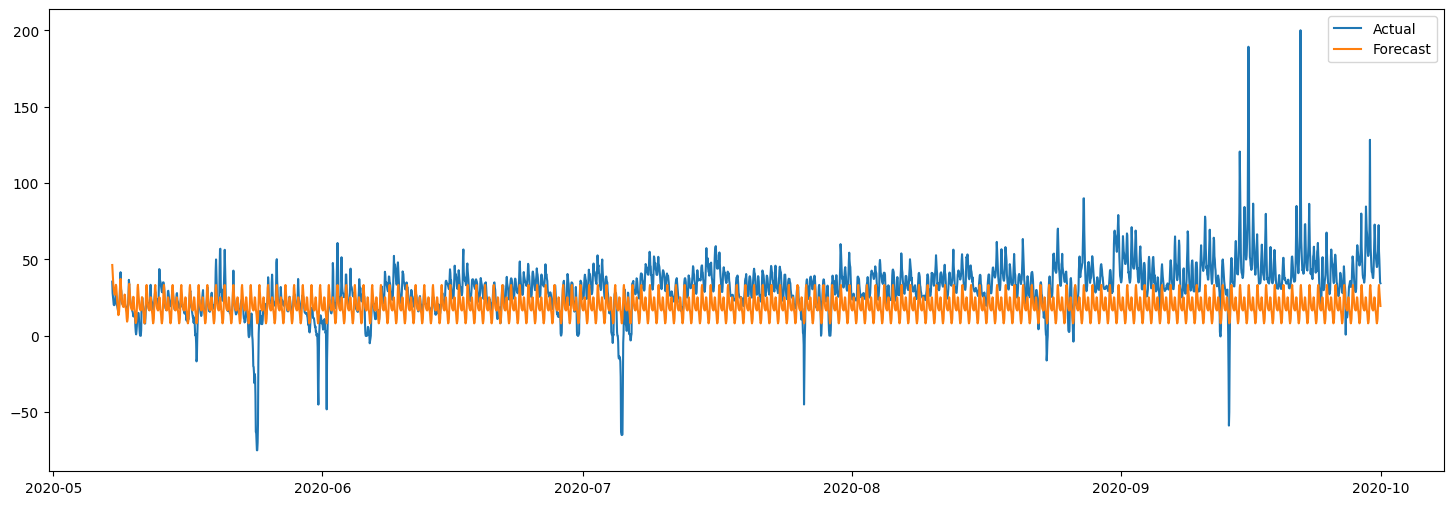

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(test.index,
         test,
         label='Actual')

plt.plot(test.index,
         forecast,
         label='Forecast')

plt.legend()

plt.show()

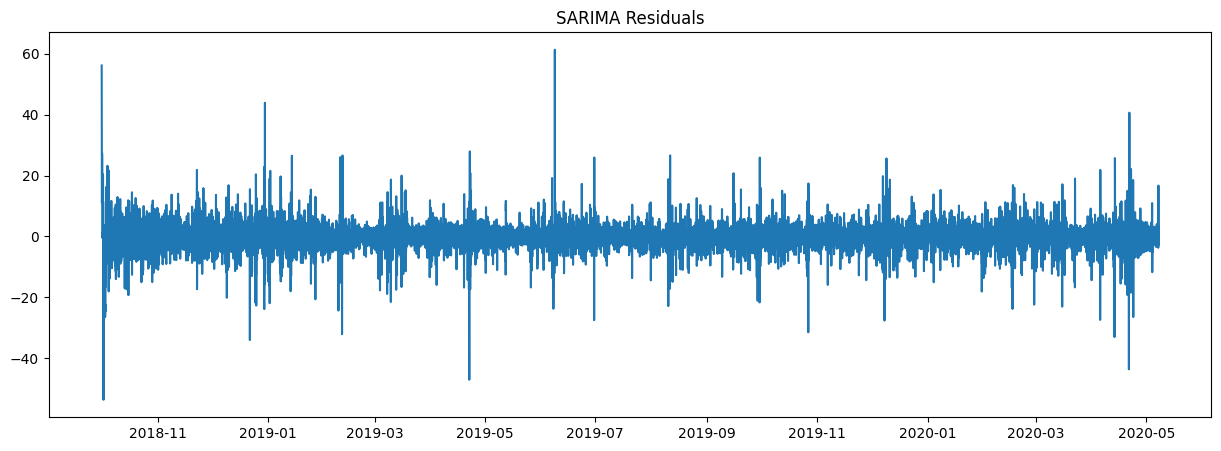

In [35]:
#residual analysis
residuals = results.resid

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(residuals)
plt.title('SARIMA Residuals')
plt.show()

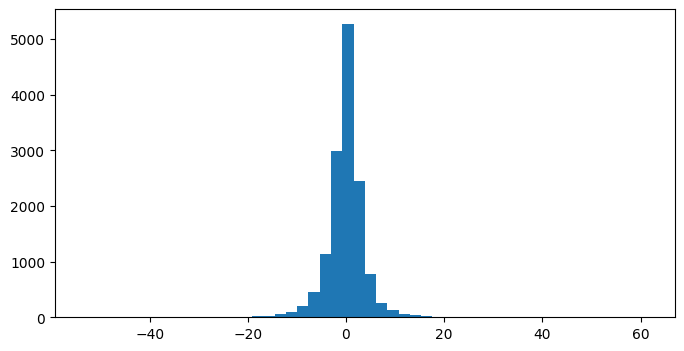

In [36]:
#destribution of residuals
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50)
plt.show()

In [37]:
#Ljung-Box Test
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    residuals,
    lags=[24],
    return_df=True
)

print(lb)

       lb_stat     lb_pvalue
24  242.470647  5.103361e-38


In [38]:
#Jarque-Bera in residuals
from scipy.stats import jarque_bera

print(
    jarque_bera(residuals)
)

SignificanceResult(statistic=np.float64(228633.39881854664), pvalue=np.float64(0.0))


In [39]:
#ARCH Test in residuals
from statsmodels.stats.diagnostic import het_arch

print(
    het_arch(residuals)
)

(np.float64(673.0716624108129), np.float64(3.779521269435304e-138), 70.64542428835182, 1.1740155907772154e-141)


In [40]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 1.5 MB/s eta 0:00:00


In [41]:
#GARCH(1,1)
from arch import arch_model

garch = arch_model(
    residuals,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

garch_fit = garch.fit()

print(garch_fit.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 49740.66954571046
Iteration:      2,   Func. Count:     14,   Neg. LLF: 40896.46145011329
Iteration:      3,   Func. Count:     20,   Neg. LLF: 41337.71133953241
Iteration:      4,   Func. Count:     27,   Neg. LLF: 37175.613673083804
Iteration:      5,   Func. Count:     31,   Neg. LLF: 37175.48433771337
Iteration:      6,   Func. Count:     35,   Neg. LLF: 37175.39558382335
Iteration:      7,   Func. Count:     39,   Neg. LLF: 37175.395169572075
Iteration:      8,   Func. Count:     43,   Neg. LLF: 37175.39516523262
Iteration:      9,   Func. Count:     46,   Neg. LLF: 37175.395165232534
Optimization terminated successfully    (Exit mode 0)
            Current function value: 37175.39516523262
            Iterations: 9
            Function evaluations: 46
            Gradient evaluations: 9
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:             

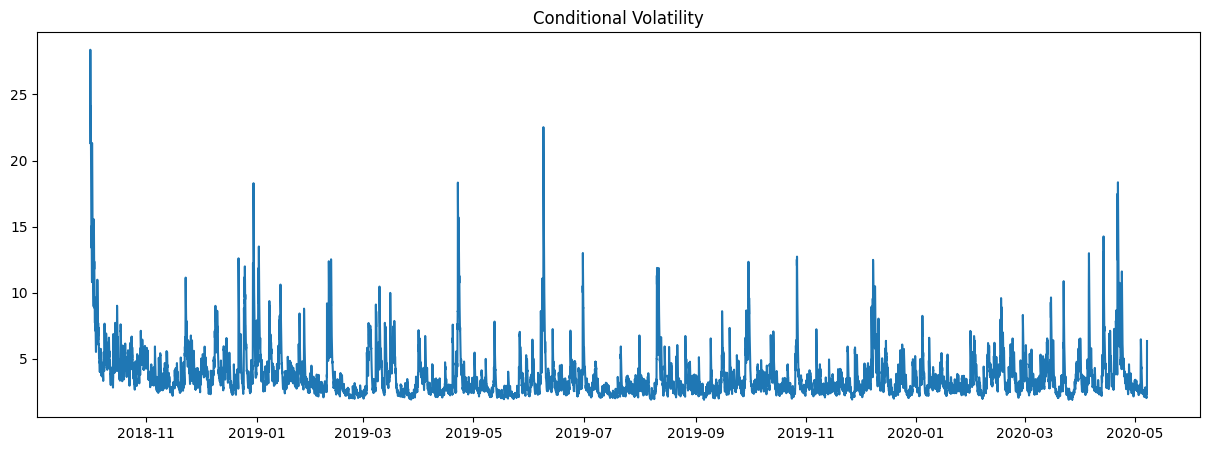

In [42]:
#Conditional Volatility
volatility = garch_fit.conditional_volatility

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(volatility)

plt.title('Conditional Volatility')

plt.show()

In [43]:
#Forecast Volatility
forecast = garch_fit.forecast(
    horizon=24
)

print(
    forecast.variance.iloc[-1]
)

h.01    35.758951
h.02    35.464730
h.03    35.176446
h.04    34.893980
h.05    34.617212
h.06    34.346030
h.07    34.080320
h.08    33.819971
h.09    33.564875
h.10    33.314927
h.11    33.070023
h.12    32.830060
h.13    32.594939
h.14    32.364563
h.15    32.138835
h.16    31.917662
h.17    31.700952
h.18    31.488615
h.19    31.280562
h.20    31.076708
h.21    30.876967
h.22    30.681256
h.23    30.489495
h.24    30.301602
Name: 2020-05-07 18:00:00+00:00, dtype: float64


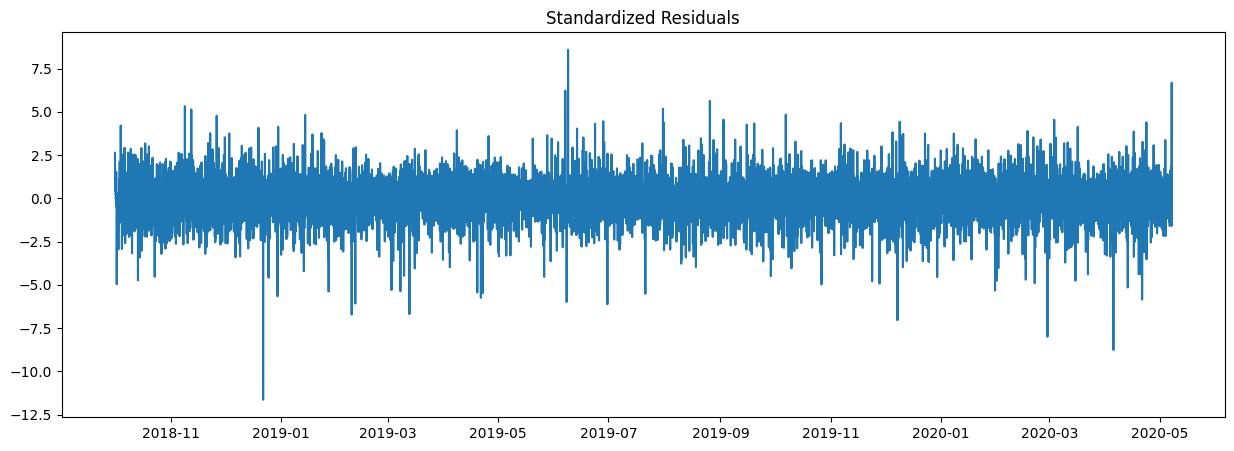

In [44]:
#Standardized Residuals
std_resid = (
    garch_fit.resid /
    garch_fit.conditional_volatility
)

plt.figure(figsize=(15,5))

plt.plot(std_resid)

plt.title(
    'Standardized Residuals'
)

plt.show()